<a href="https://colab.research.google.com/github/Shambhuraje1919/Machine_Learning_Paractice/blob/main/traning_Models_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [113]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shambhurajejagadale/student-performance-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-performance-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/student-performance-prediction-dataset


In [114]:
import pandas as pd
import os

In [115]:
os.listdir(path)

['student_dataset_10000_rows.csv']

In [116]:
df = pd.read_csv(os.path.join(path,"student_dataset_10000_rows.csv"))

In [117]:
df.head(2)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.0,Placed
1,4,69,5,3,8,56,100.0,Placed


In [118]:
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


In [119]:
df.isnull().sum()

,0
study_hours,0
attendance,0
sleep_hours,0
internet_usage,0
assignments_completed,0
previous_score,0
exam_score,0
placement_status,0


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


In [121]:
df.duplicated().sum()

np.int64(0)

In [122]:
df.head(2)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.0,Placed
1,4,69,5,3,8,56,100.0,Placed


In [123]:
from sklearn.preprocessing import LabelEncoder

In [124]:
le = LabelEncoder() #

In [125]:
le.fit(df["placement_status"])

LabelEncoder()

In [126]:
df["placement_status"] = le.transform(df["placement_status"])

In [127]:
df.head(1)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.0,1


In [128]:
x = df.drop("placement_status",axis=1)

In [129]:
y = df["placement_status"]

In [130]:
from sklearn.model_selection import train_test_split

In [131]:
from sklearn.linear_model import LogisticRegression

In [132]:
model = LogisticRegression()

In [133]:
x_train , x_test , y_train ,y_test = train_test_split(x,y,test_size= 0.2, random_state=223)

In [134]:
model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [135]:
predo =model.predict(x_test)

In [136]:
from sklearn.metrics import (accuracy_score,confusion_matrix)

In [137]:
accuracy = accuracy_score(predo,y_test)

In [138]:
accuracy

0.9995

In [139]:
print(confusion_matrix(predo,y_test))

[[ 313    1]
 [   0 1686]]


In [140]:
print(y.value_counts())

placement_status
1    8356
0    1644
Name: count, dtype: int64


In [141]:
from sklearn.ensemble import RandomForestClassifier

In [142]:
model2 = RandomForestClassifier()

In [143]:
model2.fit(x_train, y_train)

RandomForestClassifier()

In [144]:
predi2 = model2.predict(x_test)

In [145]:
accuracy2 = accuracy_score(predi2,y_test)

In [146]:
accuracy2

1.0

In [147]:
print(confusion_matrix(predi2,y_test))

[[ 313    0]
 [   0 1687]]


                 Feature  Importance
6             exam_score    0.820069
0            study_hours    0.072984
4  assignments_completed    0.042128
5         previous_score    0.030790
1             attendance    0.019370
3         internet_usage    0.007932
2            sleep_hours    0.006726


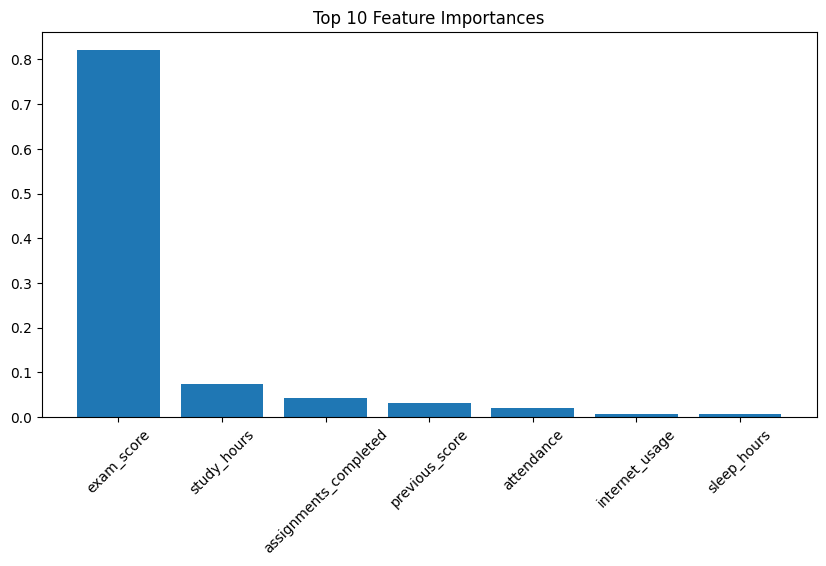

In [148]:

import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model2.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

plt.figure(figsize=(10,5))
plt.bar(importance["Feature"][:10],
        importance["Importance"][:10])

plt.xticks(rotation=45)
plt.title("Top 10 Feature Importances")
plt.show()

In [149]:
df.shape

(10000, 8)

In [150]:
print("This is the pure synthethic data thats why we got 100 percent accuracy in random forest")

This is the pure synthethic data thats why we got 100 percent accuracy in random forest


In [151]:
print("BTW This dataset created by me hehehhe")

BTW This dataset created by me hehehhe
